1. Menghasilkan properti elastis (Dengan Patahan Miring/Dipping Faults)...
2. Membuat angle-dependent wavelets...
3. Menghitung Reflektivitas dan Konvolusi...
4. Menambahkan Ambient Seismic Noise (SNR=12dB)...
5. Menampilkan visualisasi data...


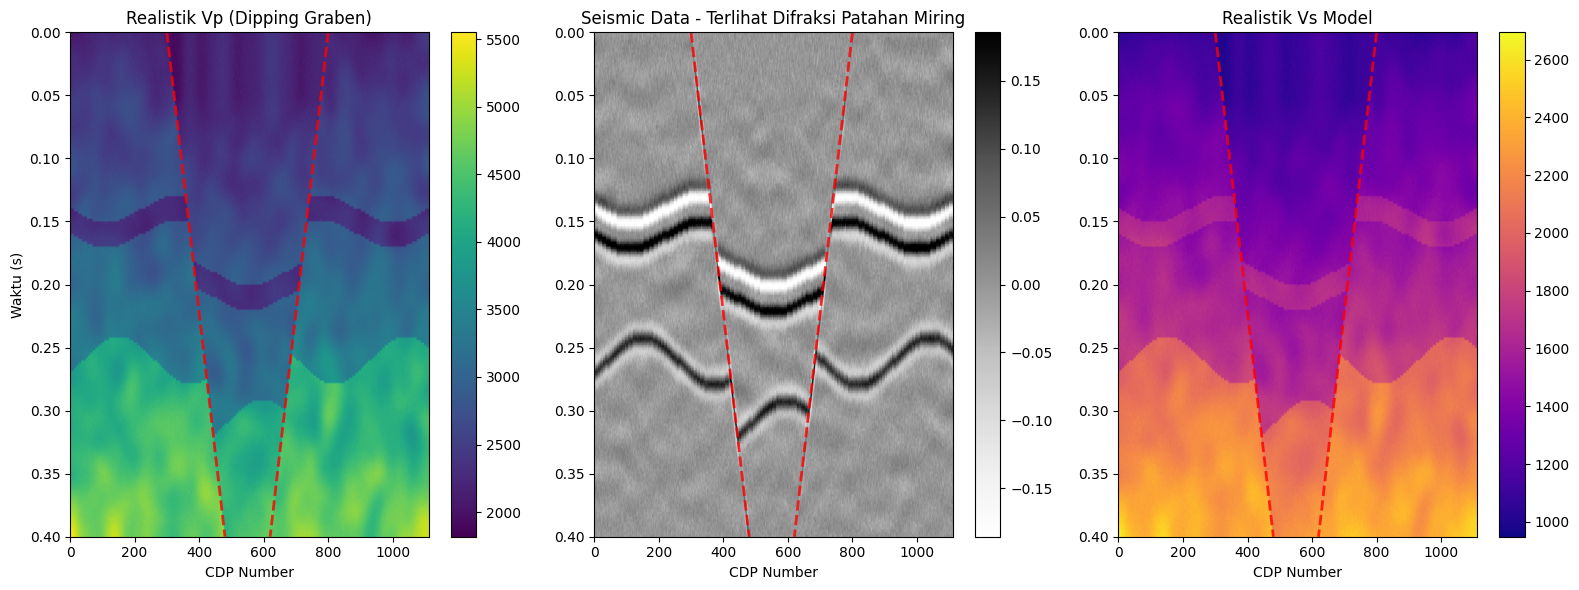

Data tersimpan: C:\Users\kunde\1.7 Prestack Inversion\realistic_dipping_fault_dataset.npz


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve
import scipy.ndimage as ndimage
import os

# =============================================================================
# 1. PARAMETER GLOBAL & SETTING
# =============================================================================
N_CDP = 1111           
NT = 200               
DT = 0.002             
ANGLES = np.array([3, 8, 13, 18, 23, 28]) 
F_DOM_BASE = 40.0      
WAV_LEN = 61           

# =============================================================================
# 2. PEMBUATAN MODEL BUMI (Patahan Miring/Dipping Faults)
# =============================================================================
def apply_dipping_graben(matrix, surf_L, surf_R, dip_L, dip_R, throw):
    """
    Mengaplikasikan patahan Graben bersudut.
    surf_L/R : Titik CDP patahan Kiri/Kanan di permukaan (z=0)
    dip_L/R  : Kemiringan (Berapa CDP bergeser per sampel waktu turun). 
               Positif = miring ke kanan, Negatif = miring ke kiri.
    throw    : Jarak pergeseran vertikal (sampel waktu) blok yang turun.
    """
    nt, n_cdp = matrix.shape
    out = np.copy(matrix)
    
    for z in range(nt):
        # Hitung posisi garis patahan pada kedalaman (waktu) z saat ini
        f_L = surf_L + z * dip_L
        f_R = surf_R + z * dip_R
        
        for x in range(n_cdp):
            # Jika posisi CDP berada di antara dua patahan (berada di Hanging Wall / blok tengah)
            if f_L <= x <= f_R:
                # Blok tengah turun sejauh 'throw'
                orig_z = np.clip(z - throw, 0, nt - 1)
                out[z, x] = matrix[orig_z, x]
    return out

def generate_highly_complex_earth_model(nt, n_cdp):
    # 1. Tren Kompaksi Dasar
    z_trend = np.linspace(0, 1, nt)
    vp = np.tile(2200 + 1800 * z_trend, (n_cdp, 1)).T
    vs = np.tile(1100 + 1000 * z_trend, (n_cdp, 1)).T
    rho = np.tile(2.10 + 0.4 * z_trend, (n_cdp, 1)).T
    
    # 2. Anomali Lensa / Fasies
    anomaly_base = np.random.randn(nt, n_cdp)
    facies_lenses = ndimage.gaussian_filter(anomaly_base, sigma=(5, 20)) 
    facies_lenses = facies_lenses / np.max(np.abs(facies_lenses))
    
    vp = vp * (1 + 0.15 * facies_lenses)
    vs = vs * (1 + 0.10 * facies_lenses)
    rho = rho * (1 + 0.05 * facies_lenses)
    
    # 3. Batas Horizon Struktural (Gelombang)
    x = np.linspace(0, 5*np.pi, n_cdp)
    h1 = int(nt * 0.35) + (6 * np.sin(x)).astype(int)
    h2 = int(nt * 0.65) + (10 * np.cos(x + 1)).astype(int)
    
    for cdp in range(n_cdp):
        idx1 = np.clip(h1[cdp], 0, nt)
        idx2 = np.clip(h2[cdp], idx1, nt)
        
        vp[idx1:idx1+10, cdp] *= 0.8  
        vs[idx1:idx1+10, cdp] *= 1.1
        rho[idx1:idx1+10, cdp] *= 0.85
        
        vp[idx2:nt, cdp] *= 1.2  
        vs[idx2:nt, cdp] *= 1.15
        rho[idx2:nt, cdp] *= 1.1
        
    # 4. Sistem Patahan Bersudut (Dipping Graben)
    # Patahan Kiri: Mulai di CDP 300, miring ke kanan (+0.9 CDP per time sample)
    # Patahan Kanan: Mulai di CDP 800, miring ke kiri (-0.9 CDP per time sample)
    # Throw: Blok tengah anjlok sedalam 25 time samples
    surf_L, surf_R = 300, 800
    dip_L, dip_R = 0.9, -0.9
    throw = 25
    
    vp = apply_dipping_graben(vp, surf_L, surf_R, dip_L, dip_R, throw)
    vs = apply_dipping_graben(vs, surf_L, surf_R, dip_L, dip_R, throw)
    rho = apply_dipping_graben(rho, surf_L, surf_R, dip_L, dip_R, throw)
    
    # 5. Noise Frekuensi Tinggi
    vp += np.random.normal(0, 30, (nt, n_cdp))
    vs += np.random.normal(0, 20, (nt, n_cdp))
    rho += np.random.normal(0, 0.02, (nt, n_cdp))
    
    return vp, vs, rho, (surf_L, surf_R, dip_L, dip_R) # Me-return parameter patahan untuk plot garis

# =============================================================================
# 3. FUNGSI FISIKA (AKI-RICHARDS & WAVELETS)
# =============================================================================
def aki_richards_reflectivity(vp, vs, rho, theta_deg):
    theta_rad = np.radians(theta_deg)
    
    dvp = np.diff(vp, axis=0)
    dvs = np.diff(vs, axis=0)
    drho = np.diff(rho, axis=0)
    
    vp_avg = vp[:-1, :] + dvp / 2.0
    vs_avg = vs[:-1, :] + dvs / 2.0
    rho_avg = rho[:-1, :] + drho / 2.0
    
    vp_avg[vp_avg == 0] = 1e-8
    vs_avg[vs_avg == 0] = 1e-8
    rho_avg[rho_avg == 0] = 1e-8
    
    A = 0.5 * (dvp/vp_avg + drho/rho_avg)
    B = 0.5 * (dvp/vp_avg) - 2 * (vs_avg/vp_avg)**2 * (2*dvs/vs_avg + drho/rho_avg)
    C = 0.5 * (dvp/vp_avg)
    
    R = A + B * np.sin(theta_rad)**2 + C * (np.sin(theta_rad)**2) * (np.tan(theta_rad)**2)
    R = np.vstack([np.zeros((1, vp.shape[1])), R])
    return R

def ricker_wavelet(f_dom, dt, length):
    t = np.arange(-length//2 + 1, length//2 + 1) * dt
    y = (1.0 - 2.0*(np.pi**2)*(f_dom**2)*(t**2)) * np.exp(-(np.pi**2)*(f_dom**2)*(t**2))
    return y

def get_angle_dependent_wavelets(angles, base_freq, dt, length):
    wavelets = []
    for theta in angles:
        f_theta = base_freq * (1.0 - 0.006 * theta)
        w = ricker_wavelet(f_theta, dt, length)
        wavelets.append(w)
    return np.array(wavelets)

def add_seismic_noise(gathers, snr_db=12): 
    signal_power = np.mean(gathers**2)
    noise_power = signal_power / (10**(snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), gathers.shape)
    return gathers + noise

# =============================================================================
# 4. PROSES GENERASI SEISMOGRAM
# =============================================================================
print("1. Menghasilkan properti elastis (Dengan Patahan Miring/Dipping Faults)...")
vp_true, vs_true, rho_true, fault_params = generate_highly_complex_earth_model(NT, N_CDP)
surf_L, surf_R, dip_L, dip_R = fault_params

print("2. Membuat angle-dependent wavelets...")
wavelets = get_angle_dependent_wavelets(ANGLES, F_DOM_BASE, DT, WAV_LEN)

seismic_gathers = np.zeros((NT, N_CDP, len(ANGLES)))

print("3. Menghitung Reflektivitas dan Konvolusi...")
for i, angle in enumerate(ANGLES):
    R_theta = aki_richards_reflectivity(vp_true, vs_true, rho_true, angle)
    current_wavelet = wavelets[i] 
    
    for cdp in range(N_CDP):
        trace_seismic = convolve(R_theta[:, cdp], current_wavelet, mode='same')
        seismic_gathers[:, cdp, i] = trace_seismic

print("4. Menambahkan Ambient Seismic Noise (SNR=12dB)...")
seismic_gathers = add_seismic_noise(seismic_gathers, snr_db=12)

# =============================================================================
# 5. VISUALISASI DATA (Menunjukkan Patahan Miring)
# =============================================================================
print("5. Menampilkan visualisasi data...")
fig, ax = plt.subplots(1, 3, figsize=(16, 6))

# Menyiapkan koordinat untuk menggambar garis patahan miring di plot
z_vals = np.array([0, NT])
y_vals = z_vals * DT # Konversi indeks z ke Waktu (s)
x_fault_L = surf_L + z_vals * dip_L
x_fault_R = surf_R + z_vals * dip_R

# Plot Vp
c1 = ax[0].imshow(vp_true, aspect='auto', cmap='viridis', extent=[0, N_CDP, NT*DT, 0])
ax[0].set_title('Realistik Vp (Dipping Graben)')
ax[0].set_ylabel('Waktu (s)')
ax[0].set_xlabel('CDP Number')
fig.colorbar(c1, ax=ax[0])
ax[0].plot(x_fault_L, y_vals, color='red', linestyle='--', linewidth=2, alpha=0.8)
ax[0].plot(x_fault_R, y_vals, color='red', linestyle='--', linewidth=2, alpha=0.8)

# Plot Seismic (3 Deg Angle)
seismic_stack = seismic_gathers[:, :, 0]
vmax = np.max(np.abs(seismic_stack)) * 0.5 

c2 = ax[1].imshow(seismic_stack, aspect='auto', cmap='Greys', vmin=-vmax, vmax=vmax, extent=[0, N_CDP, NT*DT, 0])
ax[1].set_title('Seismic Data - Terlihat Difraksi Patahan Miring')
ax[1].set_xlabel('CDP Number')
ax[1].plot(x_fault_L, y_vals, color='red', linestyle='--', linewidth=2, alpha=0.8)
ax[1].plot(x_fault_R, y_vals, color='red', linestyle='--', linewidth=2, alpha=0.8)
fig.colorbar(c2, ax=ax[1])

# Plot Vs
c3 = ax[2].imshow(vs_true, aspect='auto', cmap='plasma', extent=[0, N_CDP, NT*DT, 0])
ax[2].set_title('Realistik Vs Model')
ax[2].set_xlabel('CDP Number')
ax[2].plot(x_fault_L, y_vals, color='red', linestyle='--', linewidth=2, alpha=0.8)
ax[2].plot(x_fault_R, y_vals, color='red', linestyle='--', linewidth=2, alpha=0.8)
fig.colorbar(c3, ax=ax[2])

plt.tight_layout()
plt.show()

# =============================================================================
# 6. PENYIMPANAN DATA
# =============================================================================
output_filename = 'realistic_dipping_fault_dataset.npz'
np.savez_compressed(
    output_filename,
    seismic_gathers=seismic_gathers,
    vp_true=vp_true,
    vs_true=vs_true,
    rho_true=rho_true,
    wavelets=wavelets, 
    angles=ANGLES
)
print(f"Data tersimpan: {os.path.abspath(output_filename)}")

1. Menghasilkan Bumi dengan Hukum Fisika Batuan dan Stratigrafi...
2. Membuat angle-dependent wavelets...
3. Menghitung Reflektivitas dan Konvolusi...
4. Menambahkan Ambient Seismic Noise (Band-limited)...
5. Menampilkan visualisasi geologi...


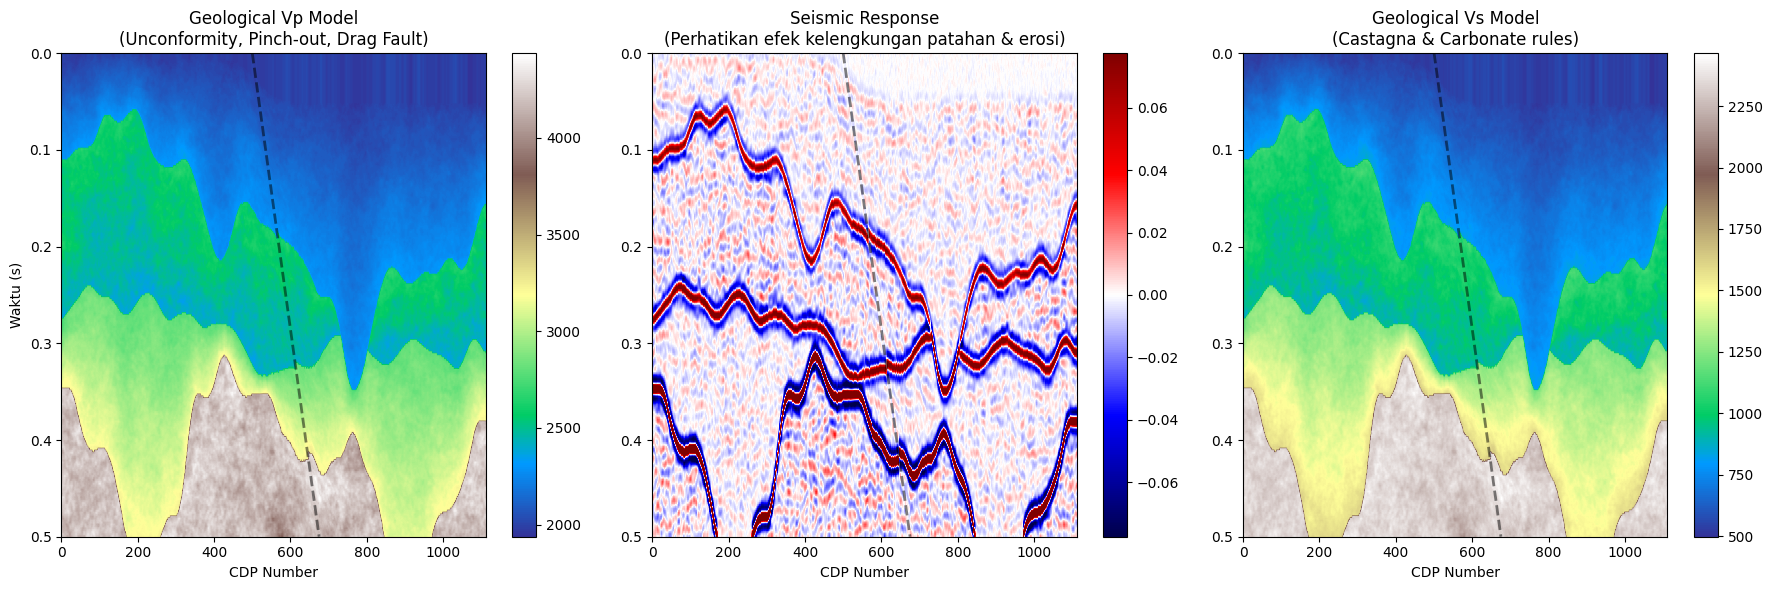

Data tersimpan: C:\Users\kunde\1.7 Prestack Inversion\advanced_geology_dataset.npz


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve
import scipy.ndimage as ndimage
import os

# =============================================================================
# 1. PARAMETER GLOBAL & SETTING
# =============================================================================
N_CDP = 1111           
NT = 250               # Diperbesar sedikit agar fitur geologi lebih terlihat
DT = 0.002             
ANGLES = np.array([3, 8, 13, 18, 23, 28]) 
F_DOM_BASE = 40.0      
WAV_LEN = 61           

# =============================================================================
# 2. GENERATOR FITUR GEOLOGI REALISTIS
# =============================================================================
def generate_fractal_noise(shape, octaves=5, persistence=0.5):
    """Menghasilkan noise fraktal (1/f) mirip log sumur geologi asli"""
    noise = np.zeros(shape)
    frequency = 1
    amplitude = 1.0
    for _ in range(octaves):
        n = np.random.randn(*shape)
        # Smoothing spasial berdasarkan frekuensi
        n = ndimage.gaussian_filter(n, sigma=(10/frequency, 30/frequency))
        noise += n * amplitude
        amplitude *= persistence
        frequency *= 2
    return noise / np.max(np.abs(noise))

def generate_horizon(n_cdp, base_z, roughness=2.0, wave_amp=10.0):
    """Menghasilkan permukaan geologi menggunakan Random Walk + Smoothing"""
    h = np.cumsum(np.random.randn(n_cdp)) * roughness
    h = ndimage.gaussian_filter(h, sigma=15)
    h = h - np.mean(h) + base_z
    h += np.sin(np.linspace(0, 3*np.pi, n_cdp)) * wave_amp
    return h.astype(int)

def apply_fault_with_drag(matrix, fault_x, dip, throw, drag_radius=20, drag_amount=0.6):
    """Patahan miring dilengkapi lipatan seret (Fault Drag) plastis"""
    nt, n_cdp = matrix.shape
    out = np.copy(matrix)
    
    for z in range(nt):
        f_x = int(fault_x + z * dip)
        
        for x in range(n_cdp):
            distance_to_fault = x - f_x
            
            # Blok Hanging Wall (Turun)
            if distance_to_fault > 0:
                # Menghitung efek tarikan/seretan ke atas mendekati patahan
                drag = np.exp(-abs(distance_to_fault) / drag_radius) * (throw * drag_amount)
                orig_z = int(np.clip(z - throw + drag, 0, nt - 1))
                out[z, x] = matrix[orig_z, x]
                
            # Blok Footwall (Naik/Tetap)
            elif distance_to_fault <= 0:
                # Efek tarikan ke bawah mendekati patahan
                drag = np.exp(-abs(distance_to_fault) / drag_radius) * (throw * drag_amount)
                orig_z = int(np.clip(z - drag, 0, nt - 1))
                out[z, x] = matrix[orig_z, x]
                
    return out

def generate_geological_earth_model(nt, n_cdp):
    vp = np.zeros((nt, n_cdp))
    
    # 1. Fondasi Fraktal
    fractal_texture = generate_fractal_noise((nt, n_cdp), octaves=5)
    
    # 2. Mendefinisikan Horizon Geologi yang Saling Memotong
    # H1: Permukaan erosional memotong lapisan di bawahnya (Unconformity)
    h1 = generate_horizon(n_cdp, base_z=int(nt*0.3), roughness=3, wave_amp=15)
    
    # H2: Lapisan sedimen tebal, di sebelah kiri tererosi oleh H1 (Pinch-out)
    h2 = generate_horizon(n_cdp, base_z=int(nt*0.55), roughness=1.5, wave_amp=-10)
    
    # H3: Top of Carbonate Build-up (Reef)
    h3 = generate_horizon(n_cdp, base_z=int(nt*0.8), roughness=4, wave_amp=20)
    
    # Menerapkan Aturan Erosi (Unconformity Rule)
    for cdp in range(n_cdp):
        h2[cdp] = max(h1[cdp], h2[cdp]) # H2 tidak boleh naik di atas H1 (Tererosi)
        h3[cdp] = max(h2[cdp], h3[cdp])
    
    # 3. Mengisi Parameter Batuan dengan Sekuen Stratigrafi
    for cdp in range(n_cdp):
        b1 = np.clip(h1[cdp], 0, nt)
        b2 = np.clip(h2[cdp], b1, nt)
        b3 = np.clip(h3[cdp], b2, nt)
        
        # Sekuen 1: Marine Shale (Homogen + Fraktal tipis)
        vp[0:b1, cdp] = 2000 + 100 * fractal_texture[0:b1, cdp] + np.linspace(0, 300, b1)
        
        # Sekuen 2: Deltaic Sandstone (Coarsening Upward: Kecepatan menurun ke atas)
        # Sifat pasir: kecepatan sedikit lebih tinggi dari shale, bervariasi karena lensa
        sand_thickness = b2 - b1
        if sand_thickness > 0:
            trend = np.linspace(2600, 2400, sand_thickness) # Vp turun di top sand
            vp[b1:b2, cdp] = trend + 200 * fractal_texture[b1:b2, cdp]
            
        # Sekuen 3: Deep Water Shale (Kompaksi tinggi)
        shale_thickness = b3 - b2
        if shale_thickness > 0:
            trend = np.linspace(2800, 3200, shale_thickness)
            vp[b2:b3, cdp] = trend + 150 * fractal_texture[b2:b3, cdp]
            
        # Sekuen 4: Karstified Carbonate (Kecepatan loncat, tekstur kasar)
        vp[b3:nt, cdp] = 4200 + 400 * fractal_texture[b3:nt, cdp]
        
    # 4. Rock Physics (Relasi Empiris Castagna & Gardner)
    # Castagna's equation (Vs dari Vp untuk clastics, perkiraan)
    vs = (vp - 1360) / 1.16 
    # Modifikasi empiris untuk Carbonate (Vs relatif lebih tinggi)
    for cdp in range(n_cdp):
        b3 = np.clip(h3[cdp], 0, nt)
        vs[b3:nt, cdp] = vp[b3:nt, cdp] / 1.8 
        
    # Gardner's equation (Densitas dari Vp)
    rho = 0.31 * (vp ** 0.25)
    
    # 5. Aplikasi Patahan Geologis (Normal Fault dengan Drag)
    # Patahan di tengah, miring ke kanan, dengan throw 25 ms
    fault_x = 500
    dip = 0.7
    vp = apply_fault_with_drag(vp, fault_x, dip, throw=25, drag_radius=30)
    vs = apply_fault_with_drag(vs, fault_x, dip, throw=25, drag_radius=30)
    rho = apply_fault_with_drag(rho, fault_x, dip, throw=25, drag_radius=30)
    
    return vp, vs, rho, fault_x, dip

# =============================================================================
# 3. FUNGSI FISIKA (AKI-RICHARDS & WAVELETS)
# =============================================================================
def aki_richards_reflectivity(vp, vs, rho, theta_deg):
    theta_rad = np.radians(theta_deg)
    
    dvp = np.diff(vp, axis=0)
    dvs = np.diff(vs, axis=0)
    drho = np.diff(rho, axis=0)
    
    vp_avg = vp[:-1, :] + dvp / 2.0
    vs_avg = vs[:-1, :] + dvs / 2.0
    rho_avg = rho[:-1, :] + drho / 2.0
    
    vp_avg[vp_avg == 0] = 1e-8
    vs_avg[vs_avg == 0] = 1e-8
    rho_avg[rho_avg == 0] = 1e-8
    
    A = 0.5 * (dvp/vp_avg + drho/rho_avg)
    B = 0.5 * (dvp/vp_avg) - 2 * (vs_avg/vp_avg)**2 * (2*dvs/vs_avg + drho/rho_avg)
    C = 0.5 * (dvp/vp_avg)
    
    R = A + B * np.sin(theta_rad)**2 + C * (np.sin(theta_rad)**2) * (np.tan(theta_rad)**2)
    R = np.vstack([np.zeros((1, vp.shape[1])), R])
    return R

def ricker_wavelet(f_dom, dt, length):
    t = np.arange(-length//2 + 1, length//2 + 1) * dt
    y = (1.0 - 2.0*(np.pi**2)*(f_dom**2)*(t**2)) * np.exp(-(np.pi**2)*(f_dom**2)*(t**2))
    return y

def get_angle_dependent_wavelets(angles, base_freq, dt, length):
    wavelets = []
    for theta in angles:
        f_theta = base_freq * (1.0 - 0.006 * theta)
        w = ricker_wavelet(f_theta, dt, length)
        wavelets.append(w)
    return np.array(wavelets)

def add_seismic_noise(gathers, snr_db=15): 
    signal_power = np.mean(gathers**2)
    noise_power = signal_power / (10**(snr_db / 10))
    # Noise juga dibuat bertekstur/band-limited (bukan white noise murni)
    noise = np.random.normal(0, np.sqrt(noise_power), gathers.shape)
    for i in range(gathers.shape[2]):
        noise[:,:,i] = ndimage.gaussian_filter(noise[:,:,i], sigma=(1.0, 0.5))
    return gathers + noise

# =============================================================================
# 4. PROSES GENERASI SEISMOGRAM
# =============================================================================
print("1. Menghasilkan Bumi dengan Hukum Fisika Batuan dan Stratigrafi...")
vp_true, vs_true, rho_true, fault_x, fault_dip = generate_geological_earth_model(NT, N_CDP)

print("2. Membuat angle-dependent wavelets...")
wavelets = get_angle_dependent_wavelets(ANGLES, F_DOM_BASE, DT, WAV_LEN)

seismic_gathers = np.zeros((NT, N_CDP, len(ANGLES)))

print("3. Menghitung Reflektivitas dan Konvolusi...")
for i, angle in enumerate(ANGLES):
    R_theta = aki_richards_reflectivity(vp_true, vs_true, rho_true, angle)
    current_wavelet = wavelets[i] 
    for cdp in range(N_CDP):
        trace_seismic = convolve(R_theta[:, cdp], current_wavelet, mode='same')
        seismic_gathers[:, cdp, i] = trace_seismic

print("4. Menambahkan Ambient Seismic Noise (Band-limited)...")
seismic_gathers = add_seismic_noise(seismic_gathers, snr_db=15)

# =============================================================================
# 5. VISUALISASI DATA TINGKAT LANJUT
# =============================================================================
print("5. Menampilkan visualisasi geologi...")
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

z_vals = np.array([0, NT])
y_vals = z_vals * DT 
f_line_x = fault_x + z_vals * fault_dip

# Plot Vp
c1 = ax[0].imshow(vp_true, aspect='auto', cmap='terrain', extent=[0, N_CDP, NT*DT, 0])
ax[0].set_title('Geological Vp Model\n(Unconformity, Pinch-out, Drag Fault)')
ax[0].set_ylabel('Waktu (s)')
ax[0].set_xlabel('CDP Number')
fig.colorbar(c1, ax=ax[0])
ax[0].plot(f_line_x, y_vals, color='black', linestyle='--', linewidth=2, alpha=0.5)

# Plot Seismic
seismic_stack = seismic_gathers[:, :, 0]
vmax = np.max(np.abs(seismic_stack)) * 0.4 

c2 = ax[1].imshow(seismic_stack, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax, extent=[0, N_CDP, NT*DT, 0])
ax[1].set_title('Seismic Response\n(Perhatikan efek kelengkungan patahan & erosi)')
ax[1].set_xlabel('CDP Number')
ax[1].plot(f_line_x, y_vals, color='black', linestyle='--', linewidth=2, alpha=0.5)
fig.colorbar(c2, ax=ax[1])

# Plot Vs (Berdasarkan Fisika Batuan)
c3 = ax[2].imshow(vs_true, aspect='auto', cmap='terrain', extent=[0, N_CDP, NT*DT, 0])
ax[2].set_title('Geological Vs Model\n(Castagna & Carbonate rules)')
ax[2].set_xlabel('CDP Number')
ax[2].plot(f_line_x, y_vals, color='black', linestyle='--', linewidth=2, alpha=0.5)
fig.colorbar(c3, ax=ax[2])

plt.tight_layout()
plt.show()

# =============================================================================
# 6. PENYIMPANAN DATA
# =============================================================================
output_filename = 'advanced_geology_dataset.npz'
np.savez_compressed(
    output_filename,
    seismic_gathers=seismic_gathers,
    vp_true=vp_true,
    vs_true=vs_true,
    rho_true=rho_true,
    wavelets=wavelets, 
    angles=ANGLES
)
print(f"Data tersimpan: {os.path.abspath(output_filename)}")